# Port Analytics: AIS Data Analysis Pipeline

Analyze AIS traffic from saved CSV/Parquet files.

**Usage:**
- Run cells in order
- Modify `DATA_FILE` and `LOOKBACK_MINUTES` to analyze different captures and time windows
- Each section is independent — run what you need

In [24]:
# ── Setup ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone, timedelta
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120



In [30]:
# Load a saved capture file
DATA_FILE = "ais_data/ais_fetch_20260608_133924.parquet"
LOOKBACK_MINUTES = 10
PORT_NAME = Path(DATA_FILE).stem.replace('ais_fetch_', '').replace('_', ' ').title()

In [31]:
# ── Load Data ──
path = Path(DATA_FILE)
if path.suffix == '.parquet':
    df = pd.read_parquet(path)
else:
    df = pd.read_csv(path)

df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
print(f'Loaded: {len(df)} rows from {DATA_FILE}')

Loaded: 45 rows from ais_data/ais_fetch_20260608_133924.parquet


---
##  1. LIVE PORT TRAFFIC (Last N minutes)

In [40]:
latest_ts = pd.to_datetime(df['timestamp'], utc=True).max()
cutoff = latest_ts - timedelta(minutes=LOOKBACK_MINUTES)
recent = df[df['timestamp'] >= cutoff].copy()

print(f'=== LIVE TRAFFIC: Last {LOOKBACK_MINUTES} minutes of captured data ===')
print(f'Reference: latest file timestamp {latest_ts}')
print(f'Data range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'Total messages: {len(recent)}')
print(f'Unique ships:   {recent["mmsi"].nunique()}')
print()

# Origin / destination overview derived from the capture itself
if len(df) > 0:
    origin_summary = (
        df.sort_values('timestamp')
          .groupby('mmsi')
          .agg(
              ship_name=('ship_name', 'first'),
              ship_type=('ship_type', 'first'),
              origin_time=('timestamp', 'first'),
              origin_latitude=('latitude', 'first'),
              origin_longitude=('longitude', 'first'),
              destination_time=('timestamp', 'last'),
              destination_latitude=('latitude', 'last'),
              destination_longitude=('longitude', 'last'),
              destination=('destination', 'last')
          )
          .reset_index()
    )
    origin_summary['origin_label'] = origin_summary.apply(
        lambda row: f"{row['origin_latitude']:.4f}, {row['origin_longitude']:.4f}", axis=1
    )
    origin_summary['destination_label'] = origin_summary.apply(
        lambda row: f"{row['destination_latitude']:.4f}, {row['destination_longitude']:.4f}", axis=1
    )
    print('Origin summary (first observed position in file):')
    display(origin_summary[['mmsi', 'ship_name', 'ship_type', 'origin_time', 'origin_label', 'destination_time', 'destination_label', 'destination']].head(20))

# By port
if 'port' in recent.columns:
    for port, g in recent.groupby('port'):
        moving = len(g[g['speed_knots'] > 1])
        stopped = len(g) - moving
        print(f'{port}: {g["mmsi"].nunique()} ships | {moving} moving | {stopped} stopped | avg {g["speed_knots"].mean():.1f} kts')
        
print()
print('Active ships:')
if len(recent) > 0:
    cols = [c for c in ['mmsi','ship_name','ship_type','speed_knots','latitude','longitude','destination','nav_status'] if c in recent.columns]
    display(recent[cols].drop_duplicates(subset=['mmsi']).head(20))

=== LIVE TRAFFIC: Last 10 minutes of captured data ===
Reference: latest file timestamp 2026-06-08 05:39:23.965104+00:00
Data range: 2026-06-08 05:28:59.568248+00:00 → 2026-06-08 05:39:23.965104+00:00
Total messages: 41
Unique ships:   14

Origin summary (first observed position in file):


,mmsi,ship_name,ship_type,origin_time,origin_label,destination_time,destination_label,destination
0,353111000,MSC SHANELLE V,,2026-06-08 05:28:59.568248+00:00,"-34.6445, -58.3415",2026-06-08 05:29:59.160974+00:00,"-34.6448, -58.3415",
1,440797000,MORNING CORNELIA,,2026-06-08 05:29:26.700705+00:00,"-34.3091, -58.5050",2026-06-08 05:38:17.068491+00:00,"-34.2998, -58.5316",
2,563050400,,,2026-06-08 05:30:00.801751+00:00,"-34.5784, -58.3672",2026-06-08 05:30:00.801751+00:00,"-34.5784, -58.3672",
3,636016606,GOODWOOD,,2026-06-08 05:29:00.998107+00:00,"-34.4055, -58.4399",2026-06-08 05:35:19.193491+00:00,"-34.3867, -58.4521",ARZAE
4,701000965,MADRE INMACULADA,,2026-06-08 05:29:00.486180+00:00,"-34.5738, -58.3823",2026-06-08 05:33:40.599658+00:00,"-34.5738, -58.3824",
5,701001304,DELTARENA,,2026-06-08 05:30:46.051033+00:00,"-34.4740, -58.3923",2026-06-08 05:36:27.361888+00:00,"-34.4670, -58.3975",
6,701001450,BIANCHE,,2026-06-08 05:31:04.389344+00:00,"-34.4222, -58.5661",2026-06-08 05:31:04.389344+00:00,"-34.4222, -58.5661",
7,701006243,EL UNO,,2026-06-08 05:30:31.704414+00:00,"-34.5744, -58.3880",2026-06-08 05:30:31.704414+00:00,"-34.5744, -58.3880",
8,701006331,CANADA,,2026-06-08 05:34:28.331431+00:00,"-34.5744, -58.3881",2026-06-08 05:34:28.331431+00:00,"-34.5744, -58.3881",
9,701006693,DASA I,,2026-06-08 05:35:55.811679+00:00,"-34.5963, -58.3410",2026-06-08 05:35:55.811679+00:00,"-34.5963, -58.3410",


: 14 ships | 22 moving | 19 stopped | avg 4.1 kts

Active ships:


,mmsi,ship_name,ship_type,speed_knots,latitude,longitude,destination,nav_status
4,701006867,SABATER R,,0.0,-34.427468,-58.558800,,Not defined
5,440797000,MORNING CORNELIA,,9.8,-34.309067,-58.505050,,Under way using engine
6,701000965,MADRE INMACULADA,,0.1,-34.573735,-58.382355,,Under way sailing
7,701007133,FADA,,0.4,-34.448247,-58.518865,,Not defined
8,353111000,MSC SHANELLE V,,0.6,-34.644783,-58.341450,,Under way using engine
10,563050400,,,0.0,-34.578410,-58.367237,,Moored
11,701006243,EL UNO,,0.0,-34.574432,-58.387978,,Under way using engine
13,701001304,DELTARENA,,5.2,-34.474045,-58.392335,,Under way using engine
15,701001450,BIANCHE,,0.0,-34.422182,-58.566067,,Not defined
19,701501000,GC 78 MADRYN,,0.0,-34.416187,-58.579492,,Under way using engine


## 2. VESSEL TYPE DISTRIBUTION

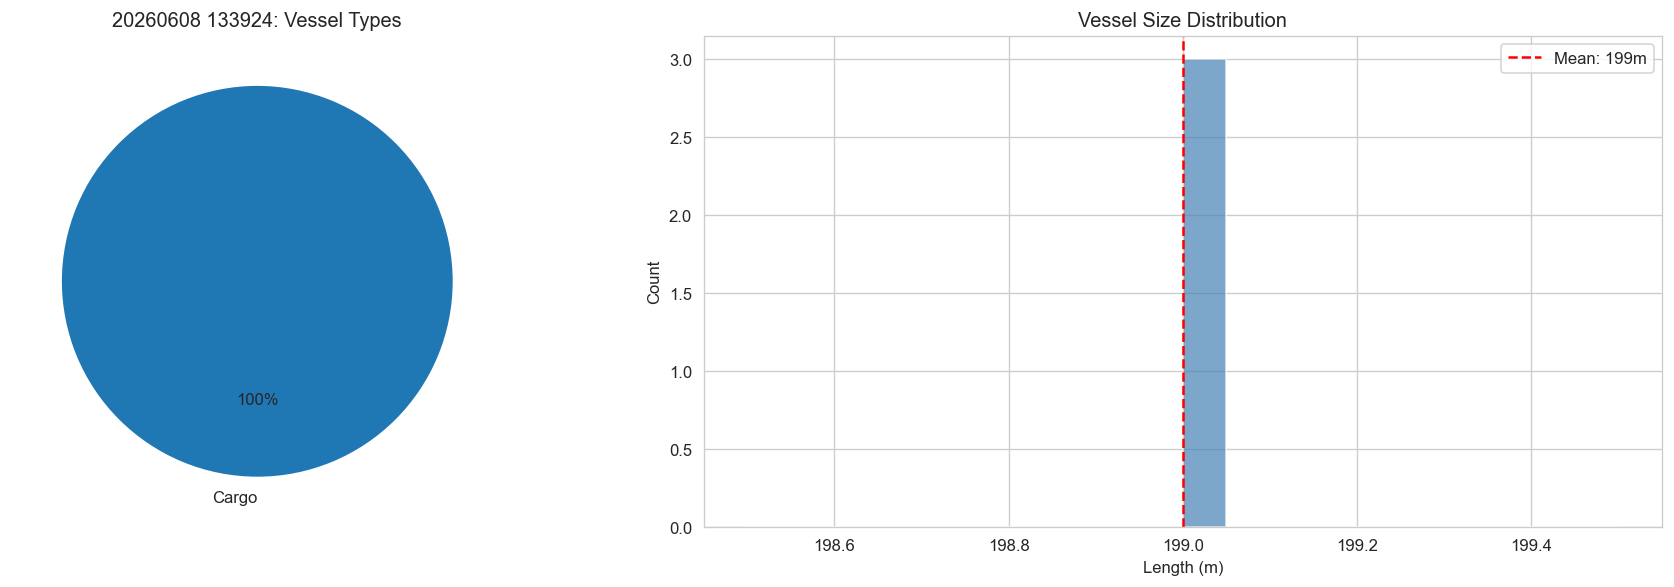


Vessel Type Summary:


,ships,messages,avg_speed
ship_type,,,
Cargo,1,3,12.07


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Type breakdown
if 'ship_type' in df.columns:
    types = df[df['ship_type'] != '']['ship_type'].value_counts()
    if len(types) > 0:
        axes[0].pie(types.values, labels=types.index, autopct='%1.0f%%', startangle=90)
        axes[0].set_title(f'{PORT_NAME}: Vessel Types')
    else:
        axes[0].text(0.5, 0.5, 'No type data', ha='center', va='center')
else:
    axes[0].text(0.5, 0.5, 'No type data', ha='center', va='center')

# Size histogram (if available)
if 'ship_length_m' in df.columns:
    sizes = df['ship_length_m'].dropna()
    if len(sizes) > 0:
        axes[1].hist(sizes, bins=20, edgecolor='white', alpha=0.7, color='steelblue')
        axes[1].axvline(sizes.mean(), color='red', linestyle='--', label=f'Mean: {sizes.mean():.0f}m')
        axes[1].set_xlabel('Length (m)')
        axes[1].set_ylabel('Count')
        axes[1].set_title('Vessel Size Distribution')
        axes[1].legend()

plt.tight_layout()
plt.show()

# Print type table
if 'ship_type' in df.columns:
    types_summary = df[df['ship_type'] != ''].groupby('ship_type').agg(
        ships=('mmsi', 'nunique'),
        messages=('mmsi', 'count'),
        avg_speed=('speed_knots', 'mean')
    ).round(2).sort_values('ships', ascending=False)
    print('\nVessel Type Summary:')
    display(types_summary)

##  3. TRAFFIC OVER TIME

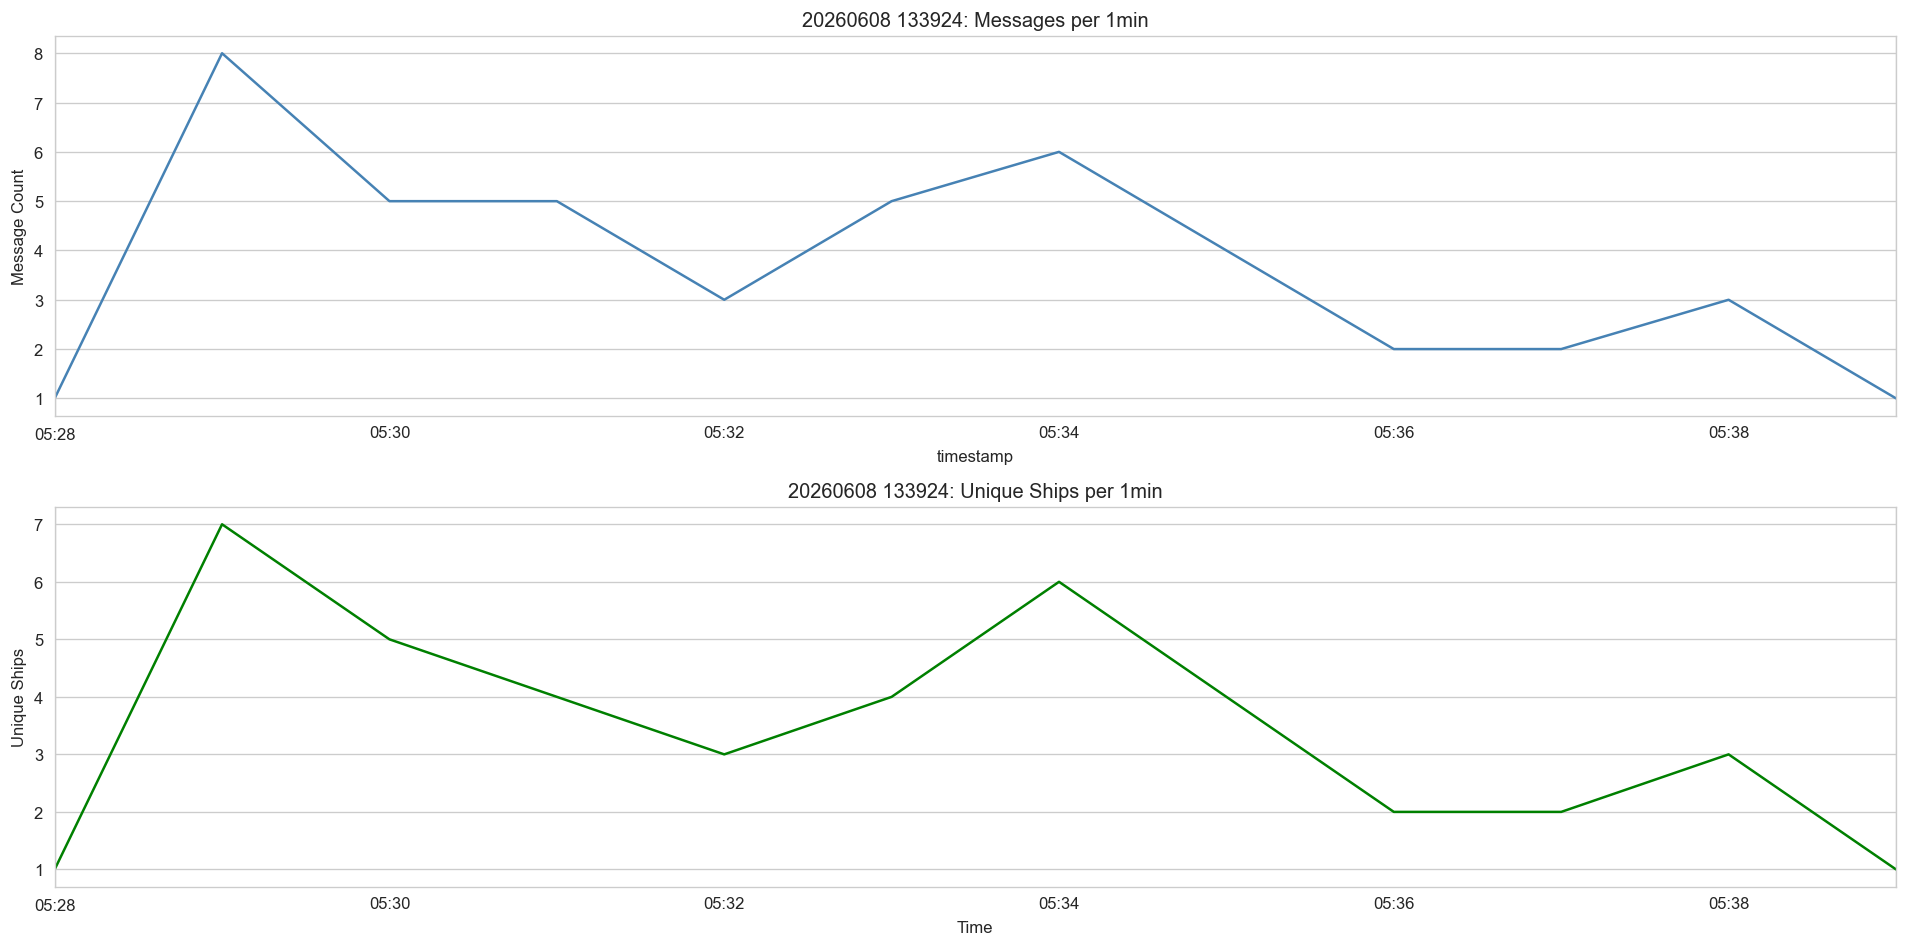

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Messages over time
df_time = df.set_index('timestamp')
if len(df_time) > 1:
    # Determine appropriate resample period
    span = (df_time.index.max() - df_time.index.min()).total_seconds()
    if span < 3600:
        rule = '1min'
    elif span < 86400:
        rule = '10min'
    else:
        rule = '1h'
    
    # Message count
    msg_counts = df_time.resample(rule).size()
    msg_counts.plot(ax=axes[0], color='steelblue')
    axes[0].set_title(f'{PORT_NAME}: Messages per {rule}')
    axes[0].set_ylabel('Message Count')
    
    # Unique ships over time
    ship_counts = df_time.resample(rule)['mmsi'].nunique()
    ship_counts.plot(ax=axes[1], color='green')
    axes[1].set_title(f'{PORT_NAME}: Unique Ships per {rule}')
    axes[1].set_ylabel('Unique Ships')
    axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

##  4. SHIP MOVEMENT ANALYSIS

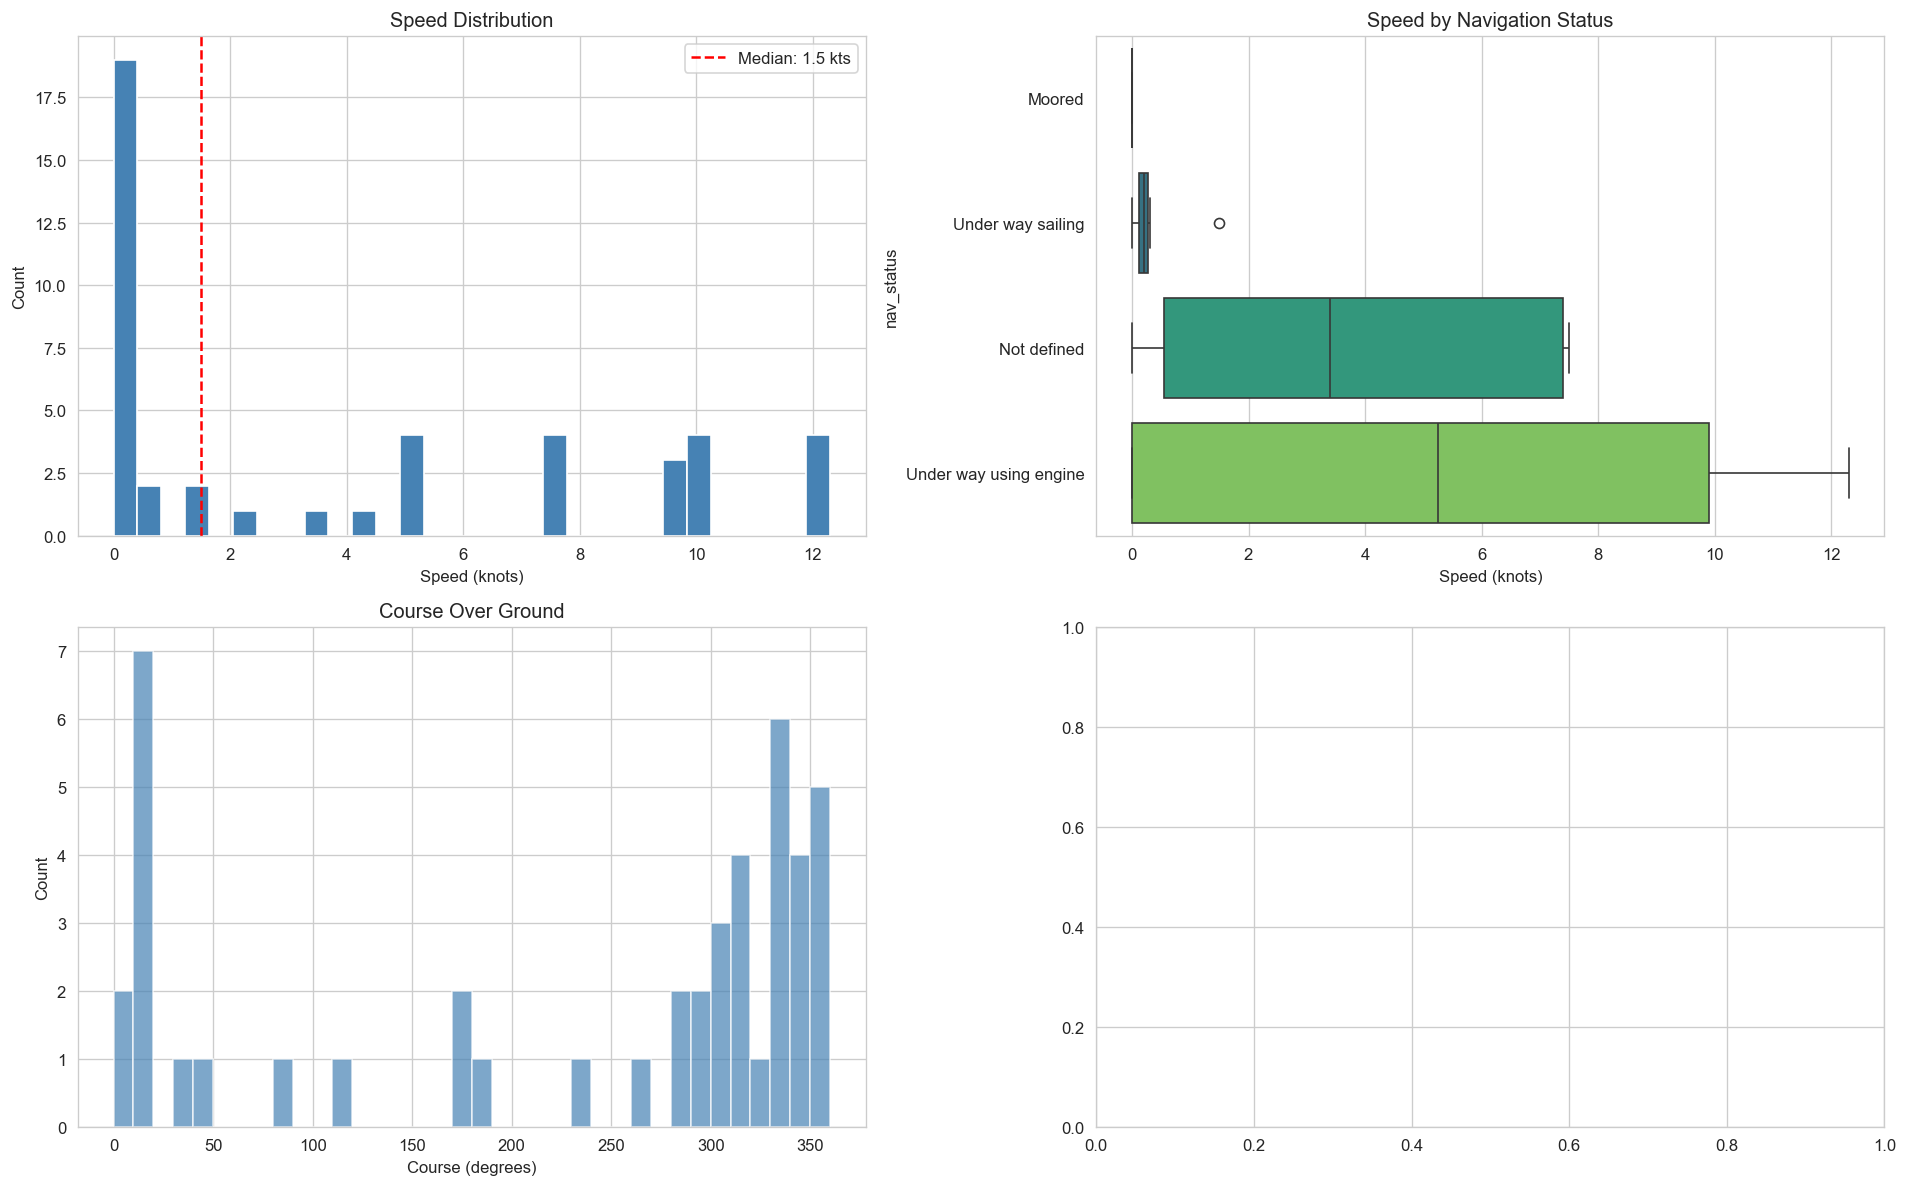

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Speed distribution
df['speed_knots'].hist(bins=30, ax=axes[0,0], edgecolor='white', color='steelblue')
axes[0,0].axvline(df['speed_knots'].median(), color='red', linestyle='--', label=f'Median: {df["speed_knots"].median():.1f} kts')
axes[0,0].set_xlabel('Speed (knots)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Speed Distribution')
axes[0,0].legend()

# Speed by nav status
if 'nav_status' in df.columns:
    status_order = df.groupby('nav_status')['speed_knots'].mean().sort_values().index
    sns.boxplot(data=df, x='speed_knots', y='nav_status', order=status_order, ax=axes[0,1], palette='viridis')
    axes[0,1].set_title('Speed by Navigation Status')
    axes[0,1].set_xlabel('Speed (knots)')
else:
    axes[0,1].text(0.5, 0.5, 'No nav status data', ha='center', va='center')

# Course over ground (direction rose)
if 'course_over_ground' in df.columns or 'heading' in df.columns:
    cog_col = 'course_over_ground' if 'course_over_ground' in df.columns else 'heading'
    axes[1,0].hist(df[cog_col].dropna(), bins=36, range=(0, 360), color='steelblue', edgecolor='white', alpha=0.7)
    axes[1,0].set_xlabel('Course (degrees)')
    axes[1,0].set_ylabel('Count')
    axes[1,0].set_title('Course Over Ground')
    
    # Cardinal directions
    def cardinal(deg):
        if pd.isna(deg): return None
        if deg >= 337.5 or deg < 22.5: return 'N'
        elif deg >= 22.5 and deg < 67.5: return 'NE'
        elif deg >= 67.5 and deg < 112.5: return 'E'
        elif deg >= 112.5 and deg < 157.5: return 'SE'
        elif deg >= 157.5 and deg < 202.5: return 'S'
        elif deg >= 202.5 and deg < 247.5: return 'SW'
        elif deg >= 247.5 and deg < 292.5: return 'W'
        else: return 'NW'
    
    dir_counts = df[cog_col].dropna().apply(cardinal).value_counts()
    for d in ['N','NE','E','SE','S','SW','W','NW']:
        if d not in dir_counts:
            dir_counts[d] = 0
    dir_counts = dir_counts[['N','NE','E','SE','S','SW','W','NW']]
    
# Speed vs ship length
if 'ship_length_m' in df.columns:
    scatter = df.dropna(subset=['ship_length_m', 'speed_knots'])
    if len(scatter) > 20:
        sc = axes[1,1].scatter(scatter['ship_length_m'], scatter['speed_knots'], 
                              c=scatter['course_over_ground'] if 'course_over_ground' in scatter.columns else scatter['speed_knots'],
                              alpha=0.6, cmap='viridis', s=30)
        axes[1,1].set_xlabel('Ship Length (m)')
        axes[1,1].set_ylabel('Speed (knots)')
        axes[1,1].set_title('Speed vs Ship Size')
        plt.colorbar(sc, ax=axes[1,1], label='COG (deg)' if 'course_over_ground' in scatter.columns else 'Speed')

plt.tight_layout()
plt.show()

##  5. DESTINATION ANALYSIS

In [36]:
if 'destination' in df.columns:
    dests = df.dropna(subset=['destination'])
    dests = dests[dests['destination'].str.strip() != '']
    
    if len(dests) > 0:
        print(f'=== Ships with declared destinations: {dests["mmsi"].nunique()} ===')
        print()
        
        # Show ships and their destinations
        dest_summary = dests.groupby(['ship_name', 'destination']).agg(
            messages=('mmsi', 'count'),
            ship_type=('ship_type', 'first')
        ).reset_index()
        
        for _, r in dest_summary.iterrows():
            name = str(r['ship_name']).strip() if str(r['ship_name']).strip() else 'Unnamed'
            print(f'  • {name:25s} → {str(r["destination"]).strip():20s} ({r["ship_type"]})')
    else:
        print('No destination data available')
else:
    print('No destination column in data')

=== Ships with declared destinations: 1 ===

  • GOODWOOD                  → ARZAE                (Cargo)


##  6. NOTABLE VESSELS

In [37]:
print('=== LARGEST VESSELS ===')
if 'ship_length_m' in df.columns:
    largest = df.dropna(subset=['ship_length_m']).sort_values('ship_length_m', ascending=False)[['ship_name','ship_length_m','ship_type','speed_knots','destination']].drop_duplicates(subset='ship_name').head(10)
    for _, r in largest.iterrows():
        n = str(r['ship_name']).strip() or 'Unnamed'
        d = str(r['destination']).strip() if str(r['destination']).strip() else '?'
        print(f'  🔵 {n:30s} {r["ship_length_m"]:4.0f}m | {r["ship_type"]:15s} | {r["speed_knots"]:5.1f} kts | → {d}')

print()
print('=== FASTEST UNDERWAY ===')
fastest = df[df['speed_knots'] > 5].sort_values('speed_knots', ascending=False)[['ship_name','speed_knots','ship_type','course_over_ground']].drop_duplicates(subset='ship_name').head(10)
for _, r in fastest.iterrows():
    n = str(r['ship_name']).strip() or 'Unnamed'
    print(f'  🟢 {n:30s} {r["speed_knots"]:5.1f} kts | {r["ship_type"]:15s} | heading {r["course_over_ground"]:3.0f}°')

print()
print('=== MOST PERSISTENT (most messages) ===')
top_msgs = df['ship_name'].value_counts().head(10)
for name, count in top_msgs.items():
    if str(name).strip():
        d = df[df['ship_name'] == name].iloc[0]
        print(f'  📡 {str(name):30s} {count:3d} messages | {d["ship_type"]:15s}')

=== LARGEST VESSELS ===
  🔵 GOODWOOD                        199m | Cargo           |  12.1 kts | → ARZAE

=== FASTEST UNDERWAY ===
  🟢 GOODWOOD                        12.3 kts |                 | heading 332°
  🟢 MORNING CORNELIA                10.1 kts |                 | heading 280°
  🟢 SABATER R                        7.5 kts |                 | heading 315°
  🟢 DELTARENA                        5.3 kts |                 | heading 344°

=== MOST PERSISTENT (most messages) ===
  📡 GC 78 MADRYN                     7 messages |                
  📡 SABATER R                        7 messages |                
  📡 MORNING CORNELIA                 7 messages |                
  📡 MADRE INMACULADA                 5 messages |                
  📡 GOODWOOD                         4 messages |                
  📡 DELTARENA                        4 messages |                
  📡 FADA                             3 messages |                
  📡 MSC SHANELLE V                   2 messages |     

##  7. FULL PORT SUMMARY

In [38]:
print('='*70)
print(f'  📍 PORT SUMMARY: {PORT_NAME}')
print('='*70)

print(f'\n  Time range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'  Duration: {(df["timestamp"].max() - df["timestamp"].min()).total_seconds()/60:.1f} minutes')
print(f'  Total messages: {len(df)}')
print(f'  Unique ships:   {df["mmsi"].nunique()}')
print()
print(f'  TRAFFIC FLOW:')
print(f'    Underway:  {len(df[df["speed_knots"] > 1])} ({(len(df[df["speed_knots"] > 1])/len(df)*100):.0f}%)')
print(f'    Stopped:   {len(df[df["speed_knots"] <= 1])} ({(len(df[df["speed_knots"] <= 1])/len(df)*100):.0f}%)')
print(f'    Avg speed: {df["speed_knots"].mean():.1f} kts (median: {df["speed_knots"].median():.1f})')
print()

if 'nav_status' in df.columns:
    print(f'  NAVIGATION STATUS:')
    for s, c in df['nav_status'].value_counts().items():
        print(f'    {s:35s} {c:4d} ({c/len(df)*100:.0f}%)')
    print()

if 'ship_type' in df.columns and df['ship_type'].nunique() > 1:
    print(f'  VESSEL TYPES:')
    for t, c in df[df['ship_type'] != '']['ship_type'].value_counts().items():
        print(f'    {t:25s} {c:3d}')
    print()

if 'ship_length_m' in df.columns:
    lengths = df['ship_length_m'].dropna()
    if len(lengths) > 0:
        print(f'  VESSEL SIZES:')
        print(f'    Length: {lengths.min():.0f} - {lengths.max():.0f} m (mean: {lengths.mean():.0f}m)')
    
print('='*70)

  📍 PORT SUMMARY: 20260608 133924

  Time range: 2026-06-08 05:28:59.568248+00:00 → 2026-06-08 05:39:23.965104+00:00
  Duration: 10.4 minutes
  Total messages: 45
  Unique ships:   14

  TRAFFIC FLOW:
    Underway:  24 (53%)
    Stopped:   21 (47%)
    Avg speed: 4.1 kts (median: 1.5)

  NAVIGATION STATUS:
    Under way using engine                26 (58%)
    Not defined                           11 (24%)
    Under way sailing                      6 (13%)
    Moored                                 2 (4%)

  VESSEL TYPES:
    Cargo                       3

  VESSEL SIZES:
    Length: 199 - 199 m (mean: 199m)


---
## Export Results

In [ ]:
# Export filtered dataset for this port
port_slug = PORT_NAME.lower().replace(' ', '_')
out_dir = Path('ais_data')
out_dir.mkdir(exist_ok=True)

csv_path = out_dir / f'port_analysis_{port_slug}.csv'
df.to_csv(csv_path, index=False)
print(f'Exported: {csv_path}')

try:
    pq_path = out_dir / f'port_analysis_{port_slug}.parquet'
    df.to_parquet(pq_path, index=False)
    print(f'Exported: {pq_path}')
except:
    pass

print(f'\nFile size: {csv_path.stat().st_size / 1024:.1f} KB')